### **Data Ingestion,Preliminary Data Analysis**

In [310]:
import seaborn as sns
import matplotlib.pyplot as plt
import zipfile
import pandas as pd
import numpy as np
import os


In [311]:
loan_df = pd.read_csv('home_loan_train.csv')

df = loan_df.copy()
#this

In [347]:
df.shape

(614, 14)

**From the question the target variables is loan approval/Status**

In [312]:
df.head(3)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y


In [313]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [314]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [315]:
df.dtypes

Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

In [316]:
#loan term in months should be categorical 
df['Loan_Amount_Term'].unique()

array([360., 120., 240.,  nan, 180.,  60., 300., 480.,  36.,  84.,  12.])

In [317]:
df.nunique()

Loan_ID              614
Gender                 2
Married                2
Dependents             4
Education              2
Self_Employed          2
ApplicantIncome      505
CoapplicantIncome    287
LoanAmount           203
Loan_Amount_Term      10
Credit_History         2
Property_Area          3
Loan_Status            2
dtype: int64

the ones with lass than 11 unique values are posibly categorical 

In [318]:
df.select_dtypes(include='number').mean()

ApplicantIncome      5403.459283
CoapplicantIncome    1621.245798
LoanAmount            146.412162
Loan_Amount_Term      342.000000
Credit_History          0.842199
dtype: float64

In [319]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ApplicantIncome,614.0,5403.459283,6109.041673,150.0,2877.5,3812.5,5795.00,81000.0
CoapplicantIncome,614.0,1621.245798,2926.248369,0.0,0.0,1188.5,2297.25,41667.0
LoanAmount,592.0,146.412162,85.587325,9.0,100.0,128.0,168.00,700.0
Loan_Amount_Term,600.0,342.000000,65.120410,12.0,360.0,360.0,360.00,480.0
Credit_History,564.0,0.842199,0.364878,0.0,1.0,1.0,1.00,1.0


from the describe table it is seen that the difference bwtween the min and max is much which signifies possible outliers the standard deviation is also too large which means that the values are widely spread apart .. from the count it shows that there are missing values in some columns

In [320]:
def  loan_term_category(x):
    if pd.isna(x): return 'Unknown'
    elif x <= 12: return 'very short'
    elif x <= 60: return 'short'
    elif x <= 180: return 'medium'
    elif x <= 360: return 'Long'
    else: return 'Very Long'
df['Loan_Amount_Term'] = pd.to_numeric(df['Loan_Amount_Term'], errors='coerce')

df['Loan_Term'] = df['Loan_Amount_Term'].apply(loan_term_category)


loan_term and loan_Amount_term are the same columns  

In [321]:
numerical =df.select_dtypes(include=['float64','int64']).columns

numerical=numerical.drop('Credit_History')

In [322]:
categorical = df.select_dtypes(include='object').columns
categorical = list(categorical)
categorical.append('Credit_History')

In [323]:
df[categorical]

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status,Loan_Term,Credit_History
0,LP001002,Male,No,0,Graduate,No,Urban,Y,Long,1.0
1,LP001003,Male,Yes,1,Graduate,No,Rural,N,Long,1.0
2,LP001005,Male,Yes,0,Graduate,Yes,Urban,Y,Long,1.0
3,LP001006,Male,Yes,0,Not Graduate,No,Urban,Y,Long,1.0
4,LP001008,Male,No,0,Graduate,No,Urban,Y,Long,1.0
...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,Rural,Y,Long,1.0
610,LP002979,Male,Yes,3+,Graduate,No,Rural,Y,medium,1.0
611,LP002983,Male,Yes,1,Graduate,No,Urban,Y,Long,1.0
612,LP002984,Male,Yes,2,Graduate,No,Urban,Y,Long,1.0


In [324]:
df[numerical].head(2)

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term
0,5849,0.0,NaN,360.0
1,4583,1508.0,128.0,360.0


fill missing values 

In [325]:
for col in categorical:
 x=df[col].mode()[0]
 df[col]=df[col].fillna(x)

for col in numerical:
  df[col]=df[col].fillna(df[col].median())


In [326]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
Loan_Term            0
dtype: int64

**now the categorical and Numericals are sorted**

In [327]:
# univariate analysis of the 
def univariate_numerical_eda(df, column):
    """
    Performs univariate EDA on a single numerical column.
    Displays summary statistics, skewness, kurtosis, histogram, KDE, and boxplot.
    """
    print(f" Feature: {column}")
    print("="*40)
    print(df[column].describe().to_frame())
    print(f"\nSkewness: {df[column].skew():.3f}")
    print(f"Kurtosis: {df[column].kurt():.3f}")

    plt.figure(figsize=(12,4))

    # Histogram + KDE
    plt.subplot(1,2,1)
    sns.histplot(df[column], kde=True, bins=30, color='teal')
    plt.title(f'\n Distribution of {column}', fontsize=13)
    plt.xlabel(column)
    plt.ylabel('Frequency')

    # Boxplot
    plt.subplot(1,2,2)
    sns.boxplot(x=df[column], color='teal')
    plt.title(f'\n Boxplot of {column}', fontsize=13)

    plt.tight_layout()
    plt.show()

    # Optional note on transformation
    if abs(df[column].skew()) > 1:
        print(f"\n {column} is highly skewed. Consider log or Box-Cox transformation.")
    elif abs(df[column].skew()) > 0.5:
        print(f"{column} is moderately skewed.")
    else:
        print(f"{column} is fairly symmetric.")


 Feature: ApplicantIncome
       ApplicantIncome
count       614.000000
mean       5403.459283
std        6109.041673
min         150.000000
25%        2877.500000
50%        3812.500000
75%        5795.000000
max       81000.000000

Skewness: 6.540
Kurtosis: 60.541


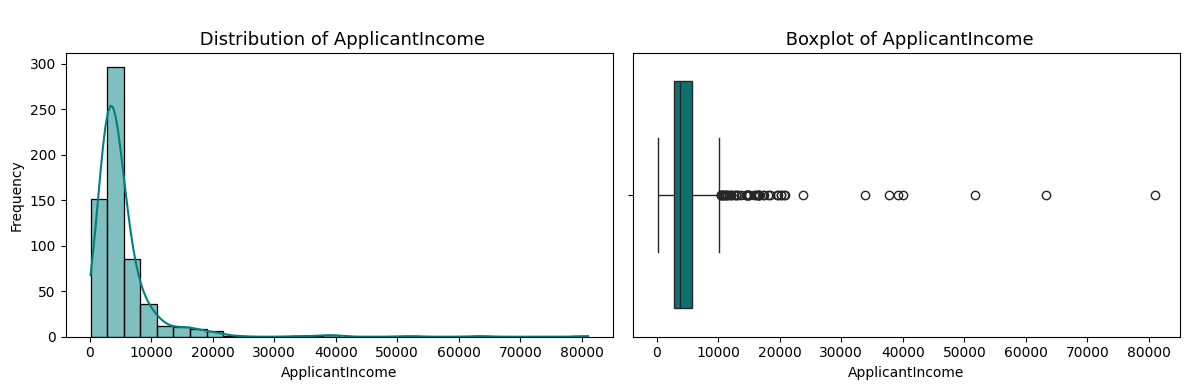


 ApplicantIncome is highly skewed. Consider log or Box-Cox transformation.
 Feature: CoapplicantIncome
       CoapplicantIncome
count         614.000000
mean         1621.245798
std          2926.248369
min             0.000000
25%             0.000000
50%          1188.500000
75%          2297.250000
max         41667.000000

Skewness: 7.492
Kurtosis: 84.956


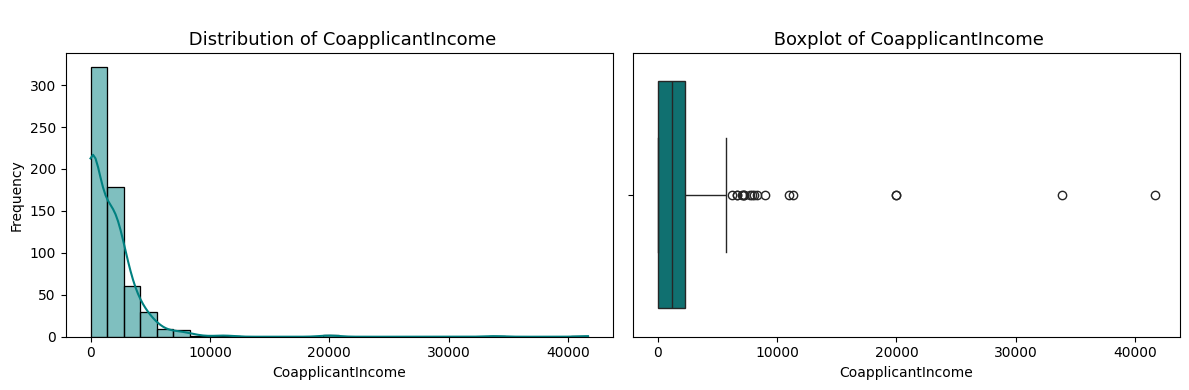


 CoapplicantIncome is highly skewed. Consider log or Box-Cox transformation.
 Feature: LoanAmount
       LoanAmount
count  614.000000
mean   145.752443
std     84.107233
min      9.000000
25%    100.250000
50%    128.000000
75%    164.750000
max    700.000000

Skewness: 2.743
Kurtosis: 10.937


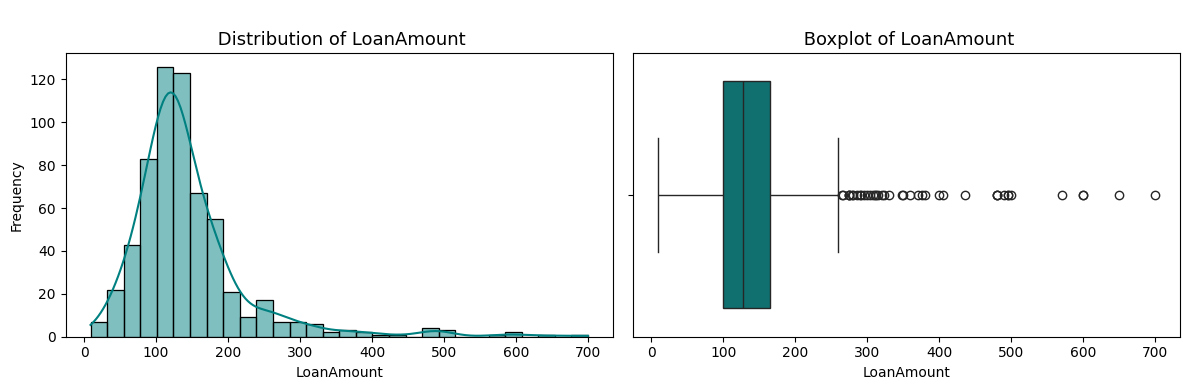


 LoanAmount is highly skewed. Consider log or Box-Cox transformation.
 Feature: Loan_Amount_Term
       Loan_Amount_Term
count        614.000000
mean         342.410423
std           64.428629
min           12.000000
25%          360.000000
50%          360.000000
75%          360.000000
max          480.000000

Skewness: -2.402
Kurtosis: 6.925


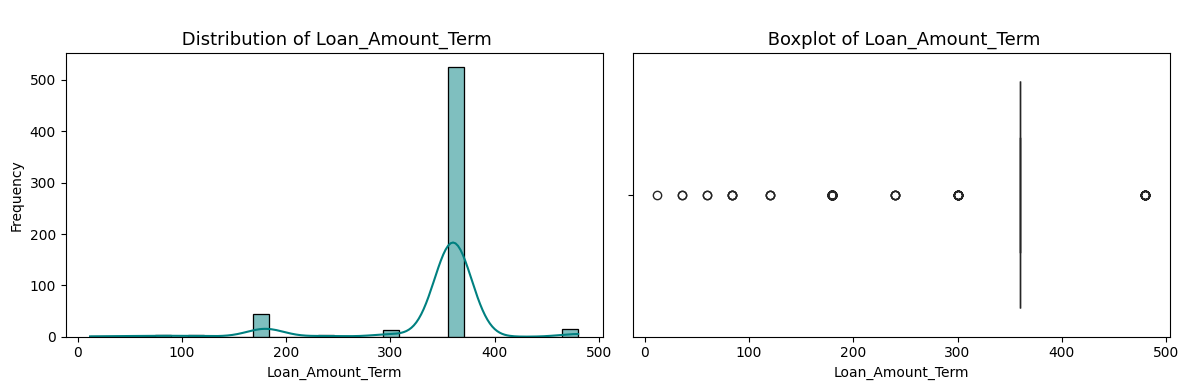


 Loan_Amount_Term is highly skewed. Consider log or Box-Cox transformation.


In [328]:
for column in numerical:
    univariate_numerical_eda(df,column)

In [329]:
categorical

['Loan_ID',
 'Gender',
 'Married',
 'Dependents',
 'Education',
 'Self_Employed',
 'Property_Area',
 'Loan_Status',
 'Loan_Term',
 'Credit_History']

In [330]:

def univariate_categorical(df, column):
    """
    Performs univariate EDA on a categorical or ordinal column.
    Displays frequency table, proportion, and a countplot.
    """
    print(f"Feature: {column}")
    print("="*40)

    # Frequency + proportion
    freq = df[column].value_counts()
    prop = df[column].value_counts(normalize=True) * 100
    summary = pd.DataFrame({'Count': freq, 'Percentage': prop.round(2)})
    print(summary)
    print()

    # Visualization
    plt.figure(figsize=(8,5))
    ax = sns.countplot(x=column, data=df, palette='Set2', order=freq.index,color='teal')
    plt.title(f'Distribution of {column}', fontsize=13)
    plt.xlabel(column)
    plt.ylabel('Count')

    # Annotate each bar with percentage
    total = len(df[column])
    for p in ax.patches:
        height = p.get_height()
        ax.text(p.get_x() + p.get_width()/2, height + 1,
                f'{(height/total)*100:.1f}%', ha='center')

    plt.tight_layout()
    plt.show()


Feature: Loan_ID
          Count  Percentage
Loan_ID                    
LP001002      1        0.16
LP001003      1        0.16
LP001005      1        0.16
LP001006      1        0.16
LP001008      1        0.16
...         ...         ...
LP002978      1        0.16
LP002979      1        0.16
LP002983      1        0.16
LP002984      1        0.16
LP002990      1        0.16

[614 rows x 2 columns]



C:\Users\ncc7888\AppData\Local\Temp\ipykernel_8440\631045517.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=column, data=df, palette='Set2', order=freq.index,color='teal')


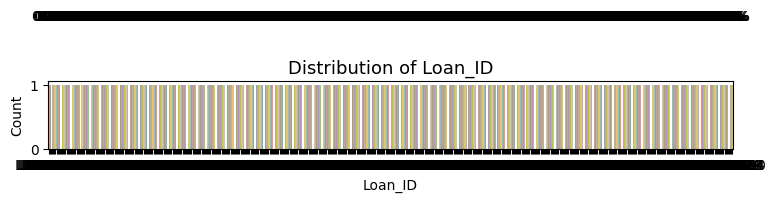

Feature: Gender
        Count  Percentage
Gender                   
Male      502       81.76
Female    112       18.24



C:\Users\ncc7888\AppData\Local\Temp\ipykernel_8440\631045517.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=column, data=df, palette='Set2', order=freq.index,color='teal')


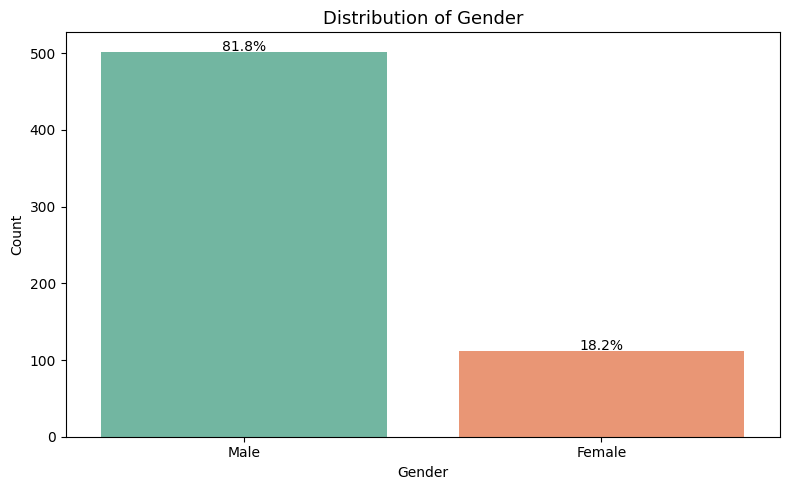

Feature: Married
         Count  Percentage
Married                   
Yes        401       65.31
No         213       34.69



C:\Users\ncc7888\AppData\Local\Temp\ipykernel_8440\631045517.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=column, data=df, palette='Set2', order=freq.index,color='teal')


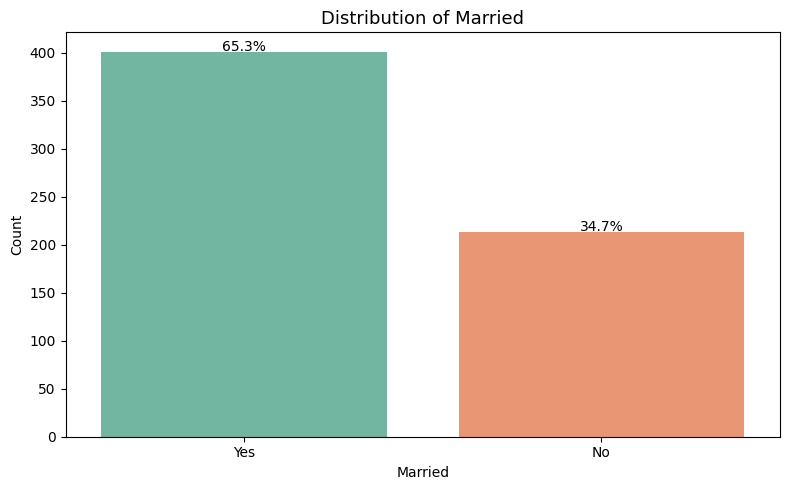

Feature: Dependents
            Count  Percentage
Dependents                   
0             360       58.63
1             102       16.61
2             101       16.45
3+             51        8.31



C:\Users\ncc7888\AppData\Local\Temp\ipykernel_8440\631045517.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=column, data=df, palette='Set2', order=freq.index,color='teal')


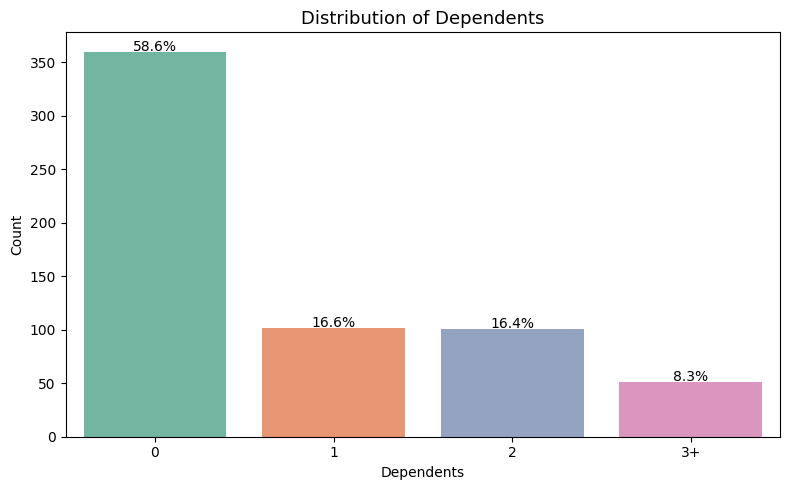

Feature: Education
              Count  Percentage
Education                      
Graduate        480       78.18
Not Graduate    134       21.82



C:\Users\ncc7888\AppData\Local\Temp\ipykernel_8440\631045517.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=column, data=df, palette='Set2', order=freq.index,color='teal')


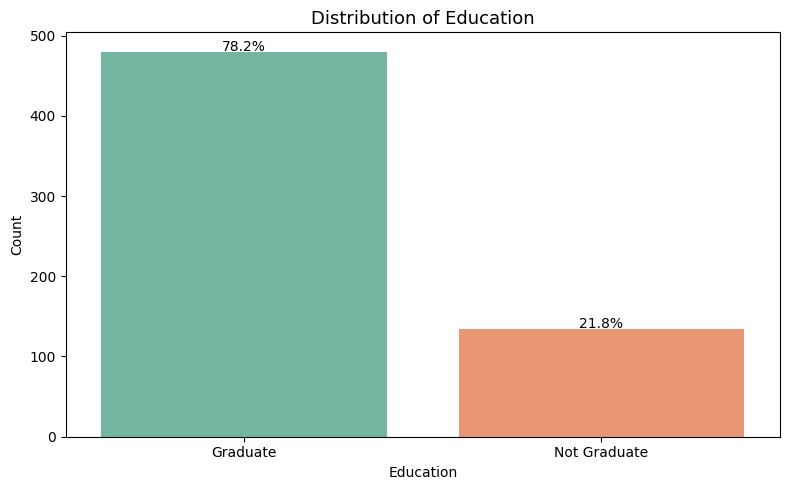

Feature: Self_Employed
               Count  Percentage
Self_Employed                   
No               532       86.64
Yes               82       13.36



C:\Users\ncc7888\AppData\Local\Temp\ipykernel_8440\631045517.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=column, data=df, palette='Set2', order=freq.index,color='teal')


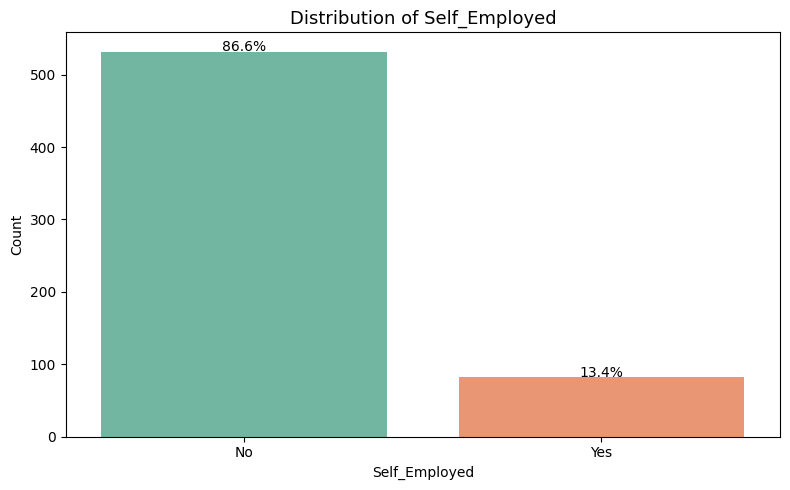

Feature: Property_Area
               Count  Percentage
Property_Area                   
Semiurban        233       37.95
Urban            202       32.90
Rural            179       29.15



C:\Users\ncc7888\AppData\Local\Temp\ipykernel_8440\631045517.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=column, data=df, palette='Set2', order=freq.index,color='teal')


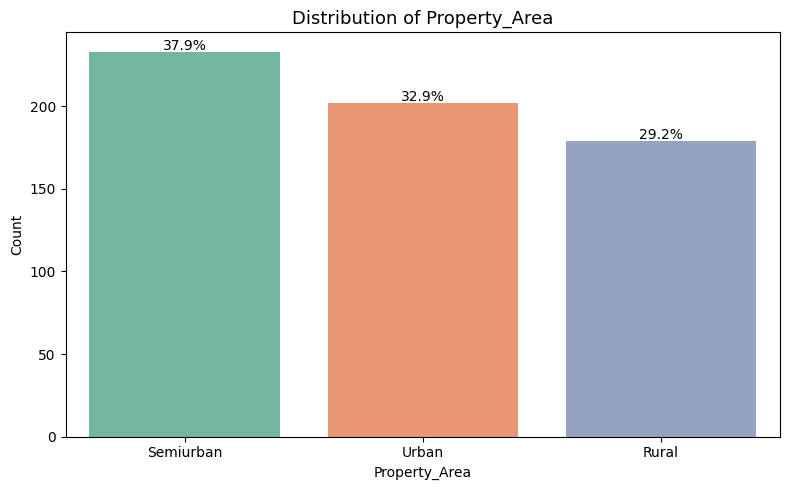

Feature: Loan_Status
             Count  Percentage
Loan_Status                   
Y              422       68.73
N              192       31.27



C:\Users\ncc7888\AppData\Local\Temp\ipykernel_8440\631045517.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=column, data=df, palette='Set2', order=freq.index,color='teal')


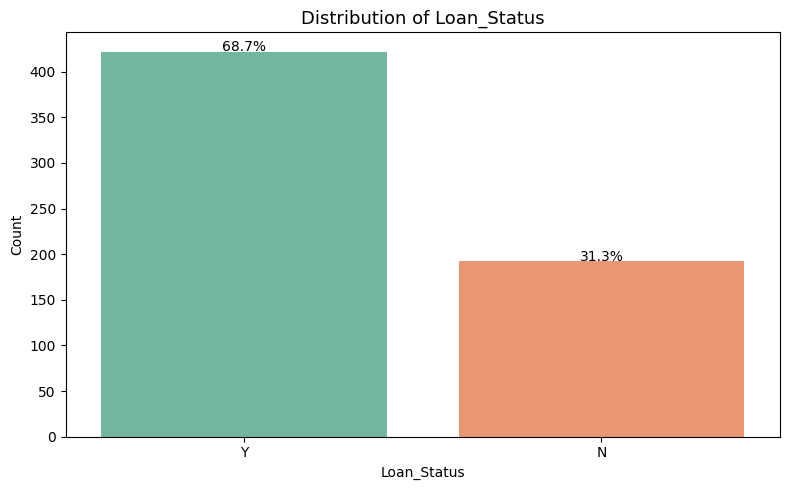

Feature: Loan_Term
            Count  Percentage
Loan_Term                    
Long          529       86.16
medium         51        8.31
Very Long      15        2.44
Unknown        14        2.28
short           4        0.65
very short      1        0.16



C:\Users\ncc7888\AppData\Local\Temp\ipykernel_8440\631045517.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=column, data=df, palette='Set2', order=freq.index,color='teal')


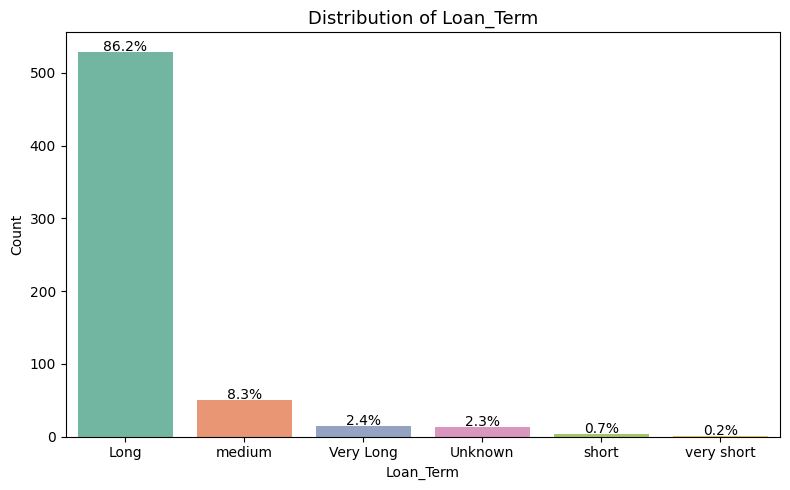

Feature: Credit_History
                Count  Percentage
Credit_History                   
1.0               525        85.5
0.0                89        14.5



C:\Users\ncc7888\AppData\Local\Temp\ipykernel_8440\631045517.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=column, data=df, palette='Set2', order=freq.index,color='teal')


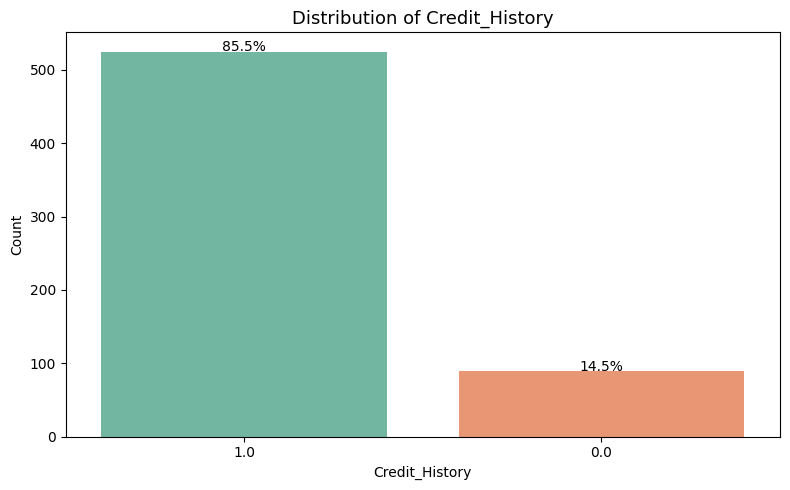

In [331]:
for column in categorical:
    univariate_categorical(df,column)

### **2.Bivariate Analysis**

In [332]:
numerical_features = pd.DataFrame(df[numerical])
numerical_features.head(2)

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term
0,5849,0.0,128.0,360.0
1,4583,1508.0,128.0,360.0


In [333]:
categorical

['Loan_ID',
 'Gender',
 'Married',
 'Dependents',
 'Education',
 'Self_Employed',
 'Property_Area',
 'Loan_Status',
 'Loan_Term',
 'Credit_History']

### Numeric to Numeric 
### Correlation with target


In [334]:
df['Loan_Status'].unique()

array(['Y', 'N'], dtype=object)

                       ApplicantIncome  CoapplicantIncome  LoanAmount  \
corr with Loan Status         -0.00471          -0.059187   -0.033214   

                       Loan_Amount_Term  
corr with Loan Status         -0.022549  


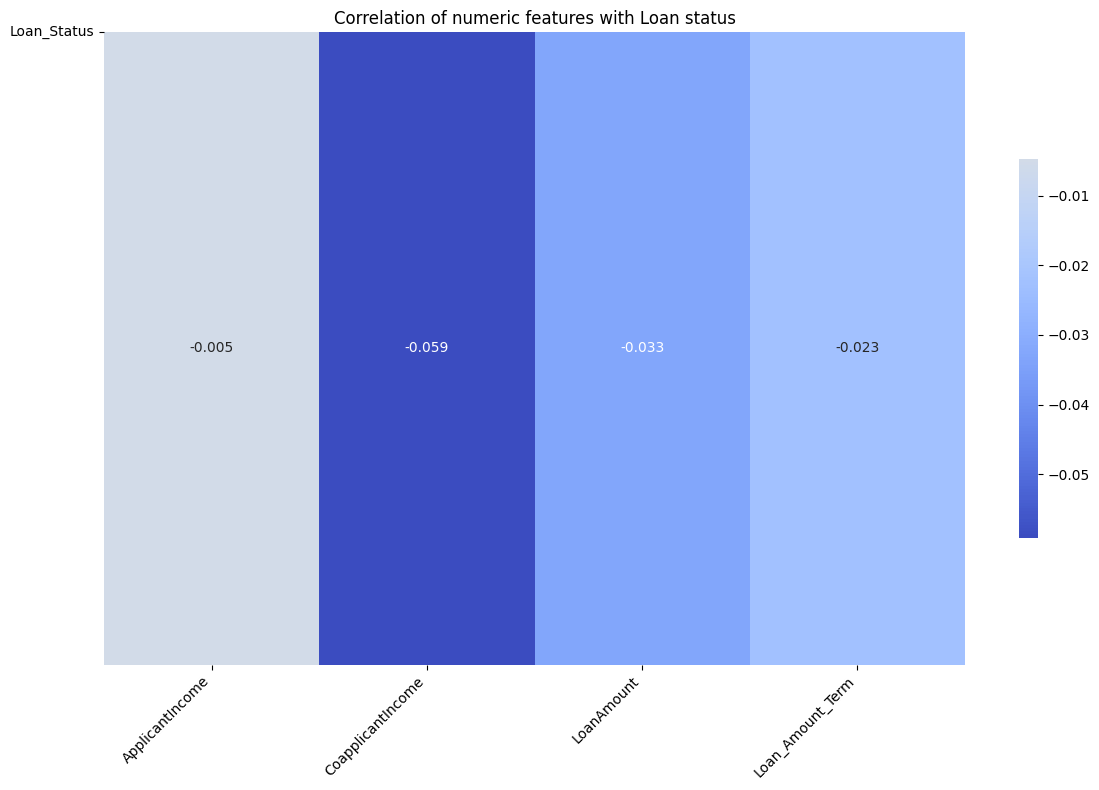

In [335]:
# def correlation_with_target(df,target)
numeric_df = df[numerical]
corrs = df[numerical].corrwith((df['Loan_Status']== 'Y').astype(int))
corr_df = corrs.to_frame(name='corr with Loan Status').T
print(corr_df)
plt.figure(figsize=(12,8))
sns.heatmap(corr_df,annot=True,fmt='.3f',cmap="coolwarm",center=0,
            cbar_kws={'orientation': 'vertical', 'shrink':0.6})

plt.xticks(rotation=45, ha='right')
plt.yticks([0], ['Loan_Status'], rotation=0)
plt.title(f'Correlation of numeric features with {'Loan status'}', fontsize=12)
plt.tight_layout()
plt.show()


In [354]:
corr_df

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term
corr with Loan Status,-0.00471,-0.059187,-0.033214,-0.022549


In [336]:
categorical.remove('Loan_Status')
categorical


['Loan_ID',
 'Gender',
 'Married',
 'Dependents',
 'Education',
 'Self_Employed',
 'Property_Area',
 'Loan_Term',
 'Credit_History']

In [337]:
df[categorical]

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Term,Credit_History
0,LP001002,Male,No,0,Graduate,No,Urban,Long,1.0
1,LP001003,Male,Yes,1,Graduate,No,Rural,Long,1.0
2,LP001005,Male,Yes,0,Graduate,Yes,Urban,Long,1.0
3,LP001006,Male,Yes,0,Not Graduate,No,Urban,Long,1.0
4,LP001008,Male,No,0,Graduate,No,Urban,Long,1.0
...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,Rural,Long,1.0
610,LP002979,Male,Yes,3+,Graduate,No,Rural,medium,1.0
611,LP002983,Male,Yes,1,Graduate,No,Urban,Long,1.0
612,LP002984,Male,Yes,2,Graduate,No,Urban,Long,1.0


In [338]:
def bivariate_num_cat(df, feature, target='quality_label'):
    """
    Plots and summarizes relationship between a numerical feature and a categorical target.
    """
    print(f" Feature: {feature} vs {target}")
    print("="*50)

    # Group summary
    summary = df.groupby(target)[feature].value_counts()
    print(summary)
    print()

    plt.figure(figsize=(10,5))

    # Boxplot + mean line
    sns.boxplot(x=target, y=feature, data=summary, palette='Set2')
    plt.title(f'{feature} across {target} categories', fontsize=13)
    plt.xlabel(target)
    plt.ylabel(feature)
    plt.show()

    # Violin plot for distribution shape
    plt.figure(figsize=(10,5))
    sns.violinplot(x=target, y=feature, data=summary, palette='Set3')
    plt.title(f'{feature} distribution by {target}', fontsize=13)
    plt.xlabel(target)
    plt.ylabel(feature)
    plt.show()


###### one numeric to categorical target

In [339]:
from sklearn.metrics import mutual_info_score


In [340]:
def mutual_score(series):
    return mutual_info_score(series,df['Loan_Status'])

In [341]:
df.apply(mutual_score)

c:\Users\ncc7888\Desktop\DataAnddata_analysis\numpyvenv\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:49: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_label = type_of_target(labels_true)
c:\Users\ncc7888\Desktop\DataAnddata_analysis\numpyvenv\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)


Loan_ID              0.621247
Gender               0.000161
Married              0.004130
Dependents           0.002618
Education            0.003591
Self_Employed        0.000007
ApplicantIncome      0.517216
CoapplicantIncome    0.289644
LoanAmount           0.203971
Loan_Amount_Term     0.012432
Credit_History       0.142400
Property_Area        0.010203
Loan_Status          0.621247
Loan_Term            0.006338
dtype: float64

### **3. Trivariate Analysis**

In [342]:
def trivariate_plot(df, x_col, y_col, hue_col):
    """
    Visualizes the relationship between two numeric variables
    with a third categorical variable shown by color (hue).
    
    Parameters
    ----------
    df : pandas.DataFrame
        The dataset.
    x_col : str
        The first numeric feature (x-axis).
    y_col : str
        The second numeric feature (y-axis).
    hue_col : str
        The categorical feature (color grouping).
    """

    plt.figure(figsize=(8, 6))
    sns.lmplot(
        data=df, 
        x=x_col, 
        y=y_col, 
        hue=hue_col, 
        height=6, 
        aspect=1.2, 
        scatter_kws={'alpha':0.6}, 
        line_kws={'linewidth':2}
    )
    plt.title(f"{y_col} vs {x_col} by {hue_col}", fontsize=13)
    plt.xlabel(x_col, fontsize=11)
    plt.ylabel(y_col, fontsize=11)
    plt.grid(alpha=0.3)
    plt.show()


In [343]:
numerical

Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term'],
      dtype='object')

<Figure size 800x600 with 0 Axes>

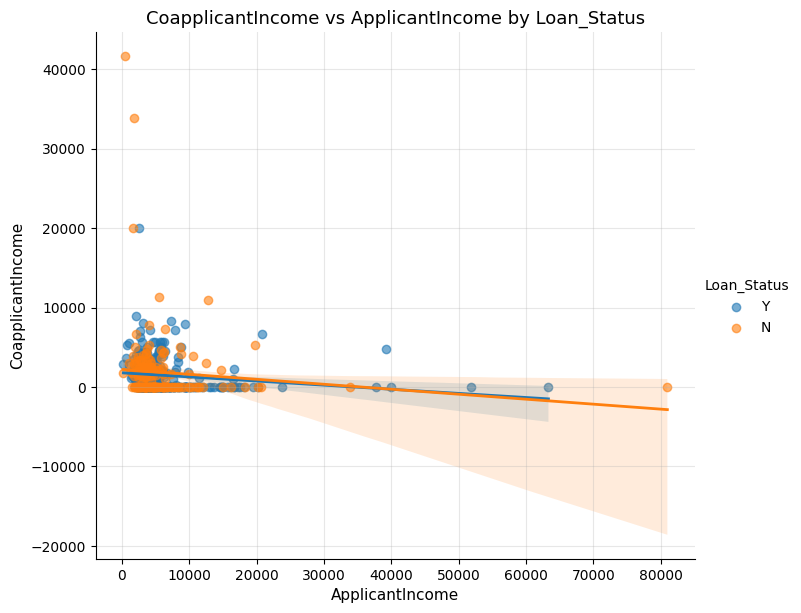

In [344]:
trivariate_plot(df,'ApplicantIncome','CoapplicantIncome','Loan_Status')

<Figure size 800x600 with 0 Axes>

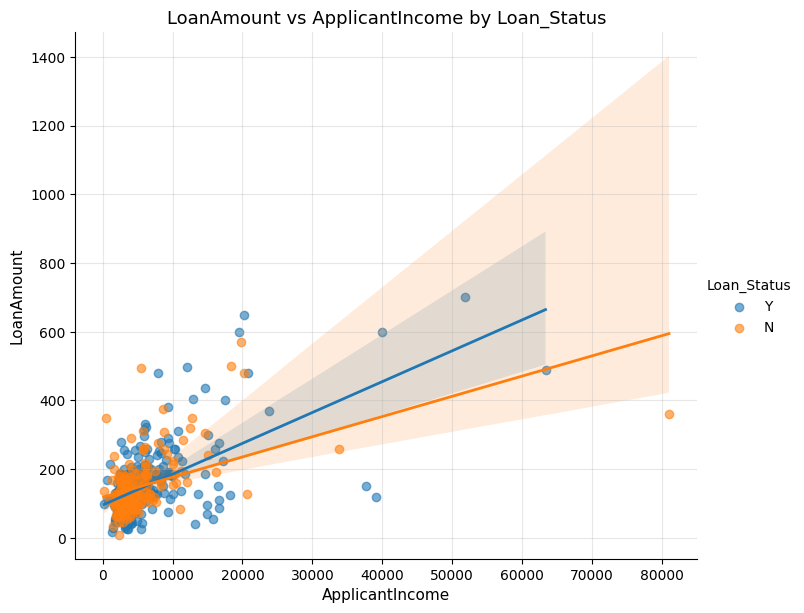

In [345]:
trivariate_plot(df,'ApplicantIncome','LoanAmount','Loan_Status')

<Figure size 800x600 with 0 Axes>

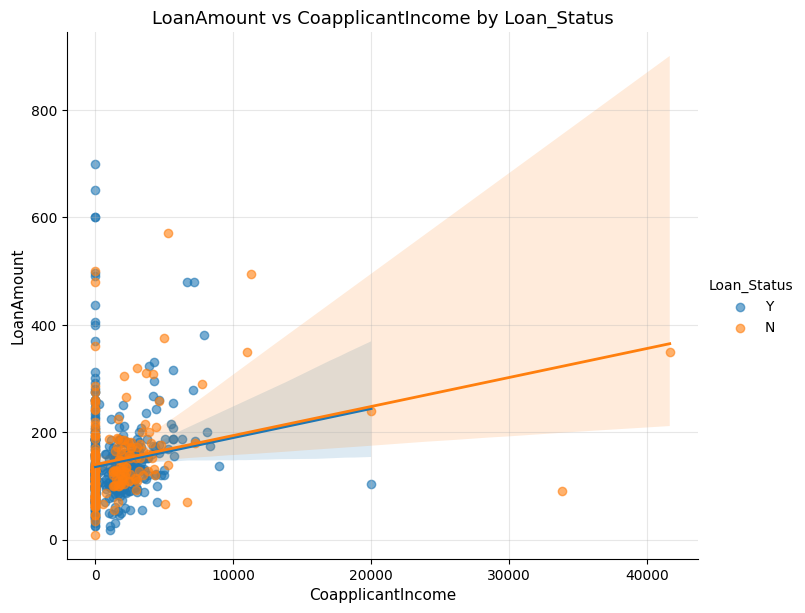

In [346]:
trivariate_plot(df,'CoapplicantIncome','LoanAmount','Loan_Status')